In [ ]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0))


CUDA available: True
GPU: NVIDIA L4


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [ ]:
!pip install pytorch-fid
!pip install torchvision
!pip install piqa



**Libraries and Device Setup**

In [ ]:
import zipfile
import io
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torch.nn as nn
import torch.optim as optim
from torchvision.utils import save_image
import torch.nn.utils.spectral_norm as spectral_norm
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


**Mount Google Drive**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
zip_path = "/content/drive/MyDrive/cyber_fusion_models/org.zip"



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Streaming ZIP Dataset Loader**

In [ ]:
zip_path = "/content/drive/MyDrive/cyber_fusion_models/org.zip"

class MalwareZipDataset(Dataset):
    def __init__(self, zip_path, transform=None):
        self.zf = zipfile.ZipFile(zip_path, "r")
        self.transform = transform

        # Load PNG files from nested folders
        self.image_files = [
            f for f in self.zf.namelist()
            if f.lower().endswith(".png") and f.count("/") >= 2
        ]

        # Class labels (folder names)
        self.labels = [f.split("/")[1] for f in self.image_files]
        self.class_names = sorted(list(set(self.labels)))
        self.class_to_idx = {cls: i for i, cls in enumerate(self.class_names)}

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_path = self.image_files[idx]
        label_name = self.labels[idx]
        label = self.class_to_idx[label_name]

        img_bytes = self.zf.read(img_path)
        img = Image.open(io.BytesIO(img_bytes)).convert("RGB")

        if self.transform:
            img = self.transform(img)

        return img, label


**Transform + Dataloader**

In [ ]:
transform = T.Compose([
    T.Resize((64, 64)),
    T.ToTensor(),
    T.Normalize(mean=[0.5, 0.5, 0.5],
                std=[0.5, 0.5, 0.5])
])

dataset = MalwareZipDataset(zip_path, transform)
loader = DataLoader(dataset, batch_size=32, shuffle=True)

print("Images:", len(dataset))
print("Classes:", len(dataset.class_names))


Images: 12569
Classes: 3


**DCGAN Hyperparameters**

In [ ]:
image_size = 64
channels_img = 3
z_dim = 100
features_g = 64
features_d = 64

epochs = 30

# --------------------------------------------------
# Instance Noise: HOLD → DECAY (Stabilization Fix)
# --------------------------------------------------
def get_instance_noise(epoch,
                       total_epochs,
                       initial_sigma=0.0,
                       hold_epochs=10):
    """
    Keeps instance noise constant in early epochs to
    prevent discriminator overconfidence, then decays
    linearly to zero.
    """
    if epoch < hold_epochs:
        return initial_sigma

    t = (epoch - hold_epochs) / max(1, total_epochs - hold_epochs)
    sigma = initial_sigma * (1 - t)
    return max(sigma, 0.0)

# Learning rates (already correct)
lr_gen  = 0.0002
lr_disc = 0.0001


**Generator**

In [ ]:
class Generator(nn.Module):
    def __init__(self, z_dim, channels_img, features_g):
        super().__init__()
        self.gen = nn.Sequential(
            # 1×1 → 4×4
            nn.ConvTranspose2d(z_dim, features_g*8, 4, 1, 0),
            nn.BatchNorm2d(features_g*8),
            nn.ReLU(True),

            # 4×4 → 8×8
            nn.ConvTranspose2d(features_g*8, features_g*4, 4, 2, 1),
            nn.BatchNorm2d(features_g*4),
            nn.ReLU(True),

            # 8×8 → 16×16
            nn.ConvTranspose2d(features_g*4, features_g*2, 4, 2, 1),
            nn.BatchNorm2d(features_g*2),
            nn.ReLU(True),

            # 16×16 → 32×32
            nn.ConvTranspose2d(features_g*2, features_g, 4, 2, 1),
            nn.BatchNorm2d(features_g),
            nn.ReLU(True),

            # ===== ADD THE REFINEMENT BLOCK HERE =====
            # 32×32 → 32×32 (no change in spatial size)
            nn.Conv2d(features_g, features_g, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(features_g),
            nn.ReLU(True),
            # ========================================

            # 32×32 → 64×64
            nn.ConvTranspose2d(features_g, channels_img, 4, 2, 1),
            nn.Tanh(),
        )

    def forward(self, x):
        return self.gen(x)


**Discriminator**

In [ ]:
class Discriminator(nn.Module):
    def __init__(self, channels_img, features_d):
        super().__init__()
        self.disc = nn.Sequential(
            spectral_norm(nn.Conv2d(channels_img, features_d, 4, 2, 1)),
            nn.LeakyReLU(0.2, inplace=True),

            spectral_norm(nn.Conv2d(features_d, features_d * 2, 4, 2, 1)),
            nn.LeakyReLU(0.2, inplace=True),

            spectral_norm(nn.Conv2d(features_d * 2, features_d * 4, 4, 2, 1)),
            nn.LeakyReLU(0.2, inplace=True),

            spectral_norm(nn.Conv2d(features_d * 4, 1, 4, 2, 0)),
            nn.Sigmoid()
        )

    def forward(self, x, sigma):
        if sigma > 0:
            x = x + torch.randn_like(x) * sigma
        return self.disc(x)


**Weights Initiallization**

In [ ]:
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
        if m.bias is not None:
            nn.init.constant_(m.bias.data, 0)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)
# disc.apply(weights_init)  # optional; SN dominates D anyway


**Loss + Optimizer for DCGAN**

In [ ]:
gen = Generator(z_dim, channels_img, features_g).to(device)
disc = Discriminator(channels_img, features_d).to(device)

gen.apply(weights_init)

opt_gen = optim.Adam(gen.parameters(), lr=lr_gen, betas=(0.5, 0.999))
opt_disc = optim.Adam(disc.parameters(), lr=lr_disc, betas=(0.5, 0.999))

criterion = nn.BCELoss()

os.makedirs("generated_samples", exist_ok=True)
fixed_noise = torch.randn(32, z_dim, 1, 1).to(device)


**DCGAN Training Loop**

In [ ]:
# =====================================================
# Ensure models are in TRAIN mode (IMPORTANT)
# =====================================================
gen.train()
disc.train()

print("gen.training:", gen.training, "disc.training:", disc.training)
print("Starting Training...\n")

# =====================================================
# Training Loop
# =====================================================
for epoch in range(epochs):

    for batch_idx, (real, _) in enumerate(loader):

        real = real.to(device)
        cur_batch_size = real.size(0)

        # ========================================
        # 1. Train Discriminator
        for _ in range(2):   # strengthen discriminator slightly
            noise = torch.randn(cur_batch_size, z_dim, 1, 1).to(device)
            fake = gen(noise).detach()

            sigma = 0.0

            real_output = disc(real, sigma)
            fake_output = disc(fake, sigma)

            real_output = real_output.mean(dim=[2, 3]).view(-1)
            fake_output = fake_output.mean(dim=[2, 3]).view(-1)

            real_labels = torch.full_like(real_output, 0.9)
            fake_labels = torch.zeros_like(fake_output)

            lossD_real = criterion(real_output, real_labels)
            lossD_fake = criterion(fake_output, fake_labels)
            lossD = (lossD_real + lossD_fake) / 2

            opt_disc.zero_grad()
            lossD.backward()
            opt_disc.step()

        # ========================================
        # 2. Train Generator
        # ========================================
# Generator update(s)
        for _ in range(1):   # <-- strengthen G
            noise = torch.randn(cur_batch_size, z_dim, 1, 1).to(device)
            fake = gen(noise)

            gen_output = disc(fake, sigma)
            gen_output = gen_output.mean(dim=[2, 3]).view(-1)

            gen_labels = torch.ones_like(gen_output)

            lossG = criterion(gen_output, gen_labels)

            opt_gen.zero_grad()
            lossG.backward()
            opt_gen.step()

        # ========================================
        # Logging (CONFIDENCE + DIAGNOSTICS)
        # ========================================
        if batch_idx % 200 == 0:
            print(
                f"Epoch [{epoch+1}/{epochs}] "
                f"Batch {batch_idx}/{len(loader)} | "
                f"D(real)={real_output.mean().item():.3f} "
                f"D(fake)={fake_output.mean().item():.3f} "
                f"sigma={sigma:.3f}"
            )

            print(
                f"D(fake) min/mean/max: "
                f"{fake_output.min().item():.3f}/"
                f"{fake_output.mean().item():.3f}/"
                f"{fake_output.max().item():.3f}"
            )

            print(
                f"Loss D: {lossD.item():.4f}, "
                f"Loss G: {lossG.item():.4f}"
            )

    # ========================================
    # Save sample images per epoch
    # ========================================
    with torch.no_grad():
        save_image(
            fake[:32],
            f"generated_samples/epoch_{epoch+1}.png",
            normalize=True
        )

print("Training Complete.")


gen.training: True disc.training: True
Starting Training...

Epoch [1/30] Batch 0/393 | D(real)=0.528 D(fake)=0.483 sigma=0.000
D(fake) min/mean/max: 0.481/0.483/0.486
Loss D: 0.6558, Loss G: 0.7651
Epoch [1/30] Batch 200/393 | D(real)=0.479 D(fake)=0.388 sigma=0.000
D(fake) min/mean/max: 0.328/0.388/0.431
Loss D: 0.6241, Loss G: 0.9839
Epoch [2/30] Batch 0/393 | D(real)=0.520 D(fake)=0.386 sigma=0.000
D(fake) min/mean/max: 0.286/0.386/0.539
Loss D: 0.5918, Loss G: 1.0081
Epoch [2/30] Batch 200/393 | D(real)=0.465 D(fake)=0.311 sigma=0.000
D(fake) min/mean/max: 0.096/0.311/0.404
Loss D: 0.6067, Loss G: 1.2156
Epoch [3/30] Batch 0/393 | D(real)=0.496 D(fake)=0.438 sigma=0.000
D(fake) min/mean/max: 0.296/0.438/0.596
Loss D: 0.6570, Loss G: 0.9460
Epoch [3/30] Batch 200/393 | D(real)=0.546 D(fake)=0.320 sigma=0.000
D(fake) min/mean/max: 0.250/0.320/0.409
Loss D: 0.5443, Loss G: 1.1592
Epoch [4/30] Batch 0/393 | D(real)=0.468 D(fake)=0.254 sigma=0.000
D(fake) min/mean/max: 0.124/0.254/0.47

**SAVE SYNTHETIC IMAGES FOR METRICS**

In [ ]:
os.makedirs("gan_generated_eval", exist_ok=True)

gen.eval()
with torch.no_grad():
    for i in range(1000):
        noise = torch.randn(1, z_dim, 1, 1).to(device)
        fake_img = gen(noise)
        save_image(fake_img, f"gan_generated_eval/fake_{i}.png", normalize=True)


**Visulas for synthetic images**

In [ ]:
num_per_class = 500  # define explicitly

synthetic_root = "synthetic_dataset/all/"
os.makedirs(synthetic_root, exist_ok=True)

gen.eval()

total_images = num_per_class * len(dataset.class_names)

with torch.no_grad():
    for i in range(total_images):
        noise = torch.randn(1, z_dim, 1, 1).to(device)
        fake = gen(noise)

        save_image(
            fake,
            f"{synthetic_root}/fake_{i}.png",
            normalize=True
        )


In [ ]:
import os

print(os.listdir("synthetic_dataset"))


['all']


In [ ]:
from PIL import Image as PILImage
Image = PILImage


**GAN samples saved during training**

In [ ]:
from IPython.display import Image as IPyImage, display
import os

folder = "generated_samples"

for file in sorted(os.listdir(folder)):
    if file.endswith(".png"):
        print("Displaying:", file)
        display(IPyImage(filename=f"{folder}/{file}"))


Output hidden; open in https://colab.research.google.com to view.

**SAVE REAL IMAGES FOR METRIC COMPARISON**

1000 real images saved.


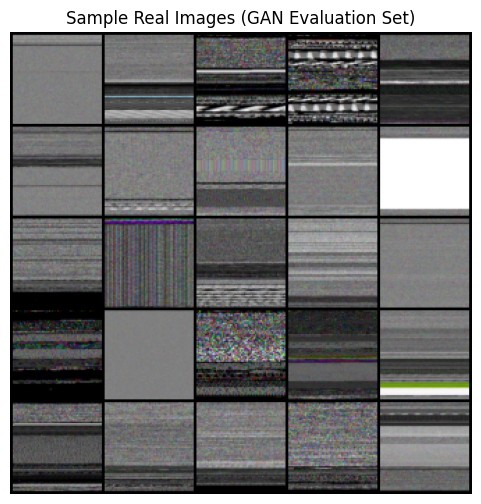

In [ ]:
import os
import torch
import matplotlib.pyplot as plt
from torchvision.utils import save_image, make_grid

os.makedirs("gan_real_eval", exist_ok=True)

count = 0
display_imgs = []   # store a few images for visualization
max_display = 25    # 5×5 grid

for imgs, _ in loader:
    for img in imgs:
        # Save image
        save_image(img, f"gan_real_eval/real_{count}.png", normalize=True)

        # Collect images for display
        if len(display_imgs) < max_display:
            display_imgs.append(img)

        count += 1
        if count >= 1000:
            break
    if count >= 1000:
        break

print("1000 real images saved.")

# ===============================
# DISPLAY IMAGE GRID
# ===============================
if len(display_imgs) > 0:
    grid = make_grid(display_imgs, nrow=5, normalize=True)

    plt.figure(figsize=(6, 6))
    plt.imshow(grid.permute(1, 2, 0))
    plt.axis("off")
    plt.title("Sample Real Images (GAN Evaluation Set)")
    plt.show()


**Compute FID**

In [ ]:
# ============================================================
# CLEAN FINAL FID EVALUATION + OPTIONAL PLOT (ONE CELL)
# ============================================================

import os
import sys
import warnings
import contextlib
import matplotlib.pyplot as plt
from pytorch_fid import fid_score

# ------------------------------------------------------------
# 1. SILENCE ALL INTERNAL OUTPUTS (tqdm, warnings, logs)
# ------------------------------------------------------------
warnings.filterwarnings("ignore")

@contextlib.contextmanager
def suppress_output():
    with open(os.devnull, "w") as devnull:
        old_stdout, old_stderr = sys.stdout, sys.stderr
        sys.stdout, sys.stderr = devnull, devnull
        try:
            yield
        finally:
            sys.stdout, sys.stderr = old_stdout, old_stderr


# ------------------------------------------------------------
# 2. FINAL FID COMPUTATION (SINGLE, CORRECT EVALUATION)
# ------------------------------------------------------------
real_folder = "gan_real_eval"
fake_folder = "gan_generated_eval"
batch_size = 32
dims = 2048

with suppress_output():
    fid_value = fid_score.calculate_fid_given_paths(
        paths=[real_folder, fake_folder],
        batch_size=batch_size,
        device=device,
        dims=dims
    )

# ------------------------------------------------------------
# 3. PRINT FINAL RESULTS ONLY
# ------------------------------------------------------------
print("\n=============== FINAL RESULTS ===============")
print(f"Final FID Score : {fid_value:.4f}")

"""
if 'fid_history' in globals() and len(fid_history) > 1:
    plt.figure(figsize=(6,4))
    plt.plot(fid_history, marker='o')
    plt.xlabel("Epoch")
    plt.ylabel("FID")
    plt.title("FID Progression During GAN Training")
    plt.grid(True)
    plt.tight_layout()
    plt.show()
"""

# ------------------------------------------------------------
# RETURN VALUE (OPTIONAL)
# ------------------------------------------------------------
fid_value



=============== FINAL RESULTS ===============
Final FID Score : 103.5077


np.float64(103.50765298624947)

In [ ]:
from piqa import SSIM
ssim_metric = SSIM().to(device)


**Compute SSIM**

=============== SSIM RESULTS ===============
Image pairs evaluated : 1000
Mean SSIM             : 0.0502
Std Deviation         : 0.0550
Min SSIM              : -0.1272
Max SSIM              : 0.5507


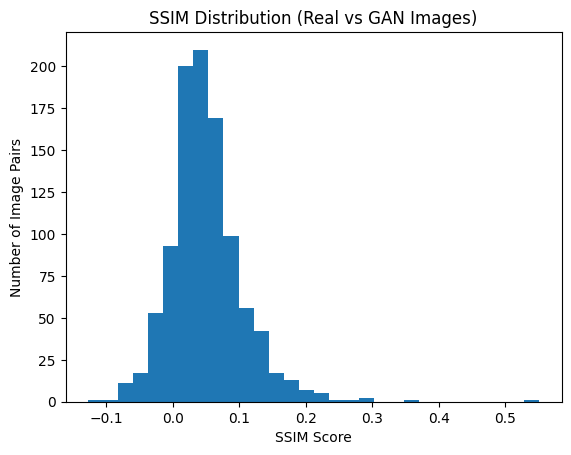

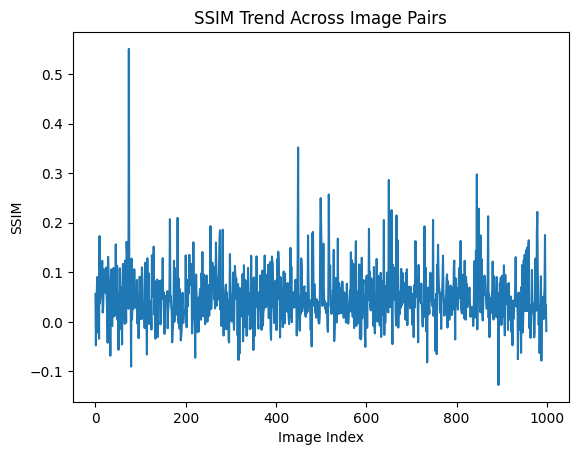

SSIM: 0.05022973711803934


In [ ]:
from PIL import Image
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from torchvision.transforms import Resize, ToTensor
from piqa import SSIM

# --------------------------------
# TRANSFORMS & METRIC
# --------------------------------
resize_64 = Resize((64, 64))
to_tensor = ToTensor()

ssim_metric = SSIM(n_channels=3).to(device)

# --------------------------------
# SSIM + PLOTS
# --------------------------------
def compute_ssim(
    real_folder="gan_real_eval",
    fake_folder="gan_generated_eval",
    max_images=1000,
    plot=True
):
    ssim_scores = []

    for i in range(max_images):
        real_path = f"{real_folder}/real_{i}.png"
        fake_path = f"{fake_folder}/fake_{i}.png"

        if not (os.path.exists(real_path) and os.path.exists(fake_path)):
            continue

        real = Image.open(real_path).convert("RGB")
        fake = Image.open(fake_path).convert("RGB")

        real = resize_64(to_tensor(real).unsqueeze(0).to(device))
        fake = resize_64(to_tensor(fake).unsqueeze(0).to(device))

        with torch.no_grad():
            ssim_value = ssim_metric(real, fake)

        ssim_scores.append(ssim_value.item())

    if len(ssim_scores) == 0:
        print("No valid image pairs found.")
        return 0.0

    ssim_scores = np.array(ssim_scores)

    # ===============================
    # NUMERICAL RESULTS
    # ===============================
    mean_ssim = ssim_scores.mean()
    std_ssim  = ssim_scores.std()
    min_ssim  = ssim_scores.min()
    max_ssim  = ssim_scores.max()

    print("=============== SSIM RESULTS ===============")
    print(f"Image pairs evaluated : {len(ssim_scores)}")
    print(f"Mean SSIM             : {mean_ssim:.4f}")
    print(f"Std Deviation         : {std_ssim:.4f}")
    print(f"Min SSIM              : {min_ssim:.4f}")
    print(f"Max SSIM              : {max_ssim:.4f}")

    # ===============================
    # PLOTS
    # ===============================
    if plot:
        # 1. Histogram
        plt.figure()
        plt.hist(ssim_scores, bins=30)
        plt.xlabel("SSIM Score")
        plt.ylabel("Number of Image Pairs")
        plt.title("SSIM Distribution (Real vs GAN Images)")
        plt.show()

        # 2. Trend plot
        plt.figure()
        plt.plot(ssim_scores)
        plt.xlabel("Image Index")
        plt.ylabel("SSIM")
        plt.title("SSIM Trend Across Image Pairs")
        plt.show()

    return mean_ssim


# Run
print("SSIM:", compute_ssim())


**Compute Entropy**

=========== ENTROPY STATISTICS ===========
Images evaluated : 1000
Mean Entropy     : 4.8432
Std Deviation    : 0.4250
Min Entropy      : 2.2807
Max Entropy      : 5.4326


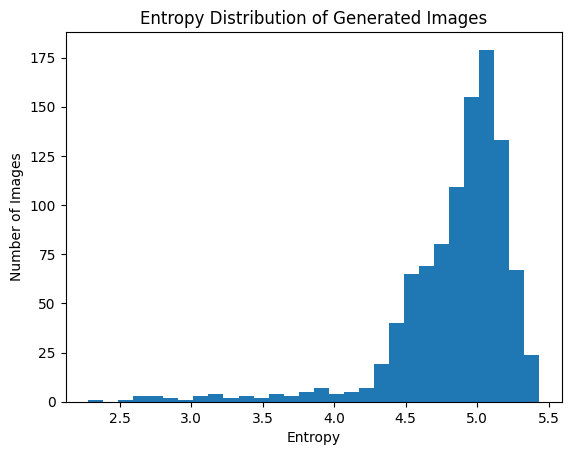

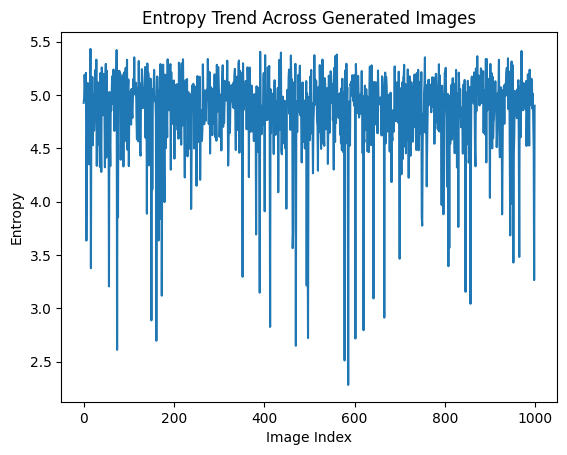

In [ ]:
# ------------------------------
# ENTROPY COMPUTATION + PLOTS
# ------------------------------

import numpy as np
from PIL import Image
import os
import matplotlib.pyplot as plt

def compute_entropy(folder="gan_generated_eval", max_images=1000, plot=True):
    entropies = []

    for i in range(max_images):
        img_path = f"{folder}/fake_{i}.png"

        if not os.path.exists(img_path):
            continue

        img = Image.open(img_path).convert("RGB")
        arr = np.array(img).flatten()

        # Histogram & entropy
        hist, _ = np.histogram(arr, bins=256, range=(0, 255), density=True)
        ent = -np.sum(hist * np.log(hist + 1e-8))
        entropies.append(ent)

    if len(entropies) == 0:
        print("No images processed.")
        return 0.0

    entropies = np.array(entropies)

    # ===============================
    # NUMERICAL RESULTS
    # ===============================
    mean_entropy = np.mean(entropies)
    std_entropy  = np.std(entropies)
    min_entropy  = np.min(entropies)
    max_entropy  = np.max(entropies)

    print("=========== ENTROPY STATISTICS ===========")
    print(f"Images evaluated : {len(entropies)}")
    print(f"Mean Entropy     : {mean_entropy:.4f}")
    print(f"Std Deviation    : {std_entropy:.4f}")
    print(f"Min Entropy      : {min_entropy:.4f}")
    print(f"Max Entropy      : {max_entropy:.4f}")

    # ===============================
    # PLOTS
    # ===============================
    if plot:
        # 1. Histogram of Entropy Values
        plt.figure()
        plt.hist(entropies, bins=30)
        plt.xlabel("Entropy")
        plt.ylabel("Number of Images")
        plt.title("Entropy Distribution of Generated Images")
        plt.show()

        # 2. Entropy per Image Index
        plt.figure()
        plt.plot(entropies)
        plt.xlabel("Image Index")
        plt.ylabel("Entropy")
        plt.title("Entropy Trend Across Generated Images")
        plt.show()

    return mean_entropy


# Run
mean_entropy = compute_entropy()


**Libraries for ResNet50**

In [ ]:

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
from torch.utils.data import DataLoader, random_split
from torchvision.datasets import ImageFolder
import numpy as np
import time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cuda')

# **Augmentation**

In [ ]:
train_transform = T.Compose([
    T.Resize((64, 64)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(15),
    T.RandomResizedCrop(64, scale=(0.8, 1.0)),
    T.ToTensor(),
    T.Normalize(
        mean=[0.485, 0.456, 0.406],      # RGB ImageNet mean
        std=[0.229, 0.224, 0.225]        # RGB ImageNet std
    )
])
test_transform = T.Compose([
    T.Resize((64, 64)),
    T.ToTensor(),
    T.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])



In [ ]:
import os, zipfile

print("=== ZIP CONTENT PREVIEW ===")
with zipfile.ZipFile(zip_path, "r") as zf:
    names = zf.namelist()
    print("Total files in ZIP:", len(names))
    print("\nFirst 50 names:")
    for f in names[:50]:
        print(f)

print("\n=== MALWAREZIPDATASET PREVIEW ===")
print("Total dataset samples:", len(dataset))
print("\nFirst 20 internal file paths:")
for i in range(20):
    print(f"{i}: {dataset.image_files[i]}  -> Label = {dataset.labels[i]}")


=== ZIP CONTENT PREVIEW ===
Total files in ZIP: 12569

First 50 names:
DETECTION_RGB_SPLIT/test/benign/0031059b-529d-4ea5-b8c2-06db664c121f--resized.png
DETECTION_RGB_SPLIT/test/benign/0035b7fd-aa61-4ccf-8d2f-08f2dfa6e1f5--resized.png
DETECTION_RGB_SPLIT/test/benign/00eea85752664955047caad7d6280bc7bf1ab91c61eb9a2542c26b747a12e963.png
DETECTION_RGB_SPLIT/test/benign/01589154-0ba2-400a-bf2f-81757a30cbcf--resized.png
DETECTION_RGB_SPLIT/test/benign/0250b75c-2eba-4c88-b455-f8c05efa6e9b--resized.png
DETECTION_RGB_SPLIT/test/benign/0276cba99c676a2310b4a04d0f702a56--resized.png
DETECTION_RGB_SPLIT/test/benign/03aed529543ac4ce2d9bb6b325f59686a06f1e9df112cf719a8e5222fffda801.png
DETECTION_RGB_SPLIT/test/benign/046041aba6ba77534c36bb0c2496408d23c6a09f930c46b392f1edc70dfd66de.png
DETECTION_RGB_SPLIT/test/benign/04c3fad7c843c2155a69e4a54fcc18324d1b4d366a0868550af02dfdd9186366.png
DETECTION_RGB_SPLIT/test/benign/0524d1cc0e49105631e29f5e13f5dd2d1eb580899297b29cf67aa9644da62e20.png
DETECTION_RGB_SPLI

In [ ]:
unique_classes = sorted(list(set(dataset.labels)))
print(unique_classes)
print("Total classes:", len(unique_classes))


['test', 'train', 'val']
Total classes: 3


**LOAD DATASETS (real + synthetic merged folder)**

In [ ]:
from sklearn.model_selection import train_test_split
import zipfile
from torch.utils.data import Dataset, DataLoader
from PIL import Image

# 1) Read all image paths directly from the ZIP
zf = zipfile.ZipFile(zip_path, "r")
all_paths = [p for p in zf.namelist() if p.lower().endswith(".png")]

# 2) Build binary labels: 0 = benign, 1 = malware
def get_binary_label(path: str) -> int:
    p = path.lower()
    if "benign" in p:
        return 0
    else:
        return 1

all_labels = [get_binary_label(p) for p in all_paths]

print("Total images:", len(all_paths))
print("Example paths and labels:")
for i in range(min(5, len(all_paths))):
    print(all_paths[i], "→", all_labels[i])

Total images: 12569
Example paths and labels:
DETECTION_RGB_SPLIT/test/benign/0031059b-529d-4ea5-b8c2-06db664c121f--resized.png → 0
DETECTION_RGB_SPLIT/test/benign/0035b7fd-aa61-4ccf-8d2f-08f2dfa6e1f5--resized.png → 0
DETECTION_RGB_SPLIT/test/benign/00eea85752664955047caad7d6280bc7bf1ab91c61eb9a2542c26b747a12e963.png → 0
DETECTION_RGB_SPLIT/test/benign/01589154-0ba2-400a-bf2f-81757a30cbcf--resized.png → 0
DETECTION_RGB_SPLIT/test/benign/0250b75c-2eba-4c88-b455-f8c05efa6e9b--resized.png → 0


**Train Test split**

In [ ]:
from sklearn.model_selection import train_test_split

# all_paths = list of image paths inside zip
# all_labels = binary labels for each path (0 benign, 1 malware)
# Ensure both are defined BEFORE this cell

train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    all_paths,
    all_labels,
    test_size=0.30,
    stratify=all_labels,
    random_state=42
)

val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths,
    temp_labels,
    test_size=0.50,   # 0.50 of 30% = 15% test, 15% val
    stratify=temp_labels,
    random_state=42
)

print("Split sizes:")
print("Train:", len(train_paths))
print("Val  :", len(val_paths))
print("Test :", len(test_paths))

# sanity check: class balance
from collections import Counter
print("Train label dist:", Counter(train_labels))
print("Val label dist  :", Counter(val_labels))
print("Test label dist :", Counter(test_labels))


Split sizes:
Train: 8798
Val  : 1885
Test : 1886
Train label dist: Counter({1: 5310, 0: 3488})
Val label dist  : Counter({1: 1138, 0: 747})
Test label dist : Counter({1: 1138, 0: 748})


**ResNet Data Loader**

In [ ]:
import io, zipfile
from PIL import Image
from torch.utils.data import Dataset
import torchvision.transforms as T

class CustomZipDataset(Dataset):
    def __init__(self, zip_path, file_list, labels, transform=None):
        self.zip_path = zip_path
        self.file_list = file_list
        self.labels = labels
        self.transform = transform
        self.zf = zipfile.ZipFile(zip_path, "r")

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        inner_path = self.file_list[idx]
        y = self.labels[idx]

        raw = self.zf.read(inner_path)
        img = Image.open(io.BytesIO(raw)).convert("RGB")

        if self.transform:
            img = self.transform(img)

        return img, y

# IMPORTANT: Ensure zip_path exists
print("ZIP:", zip_path)

train_dataset = CustomZipDataset(zip_path, train_paths, train_labels, transform=train_transform)
val_dataset   = CustomZipDataset(zip_path, val_paths,   val_labels,   transform=test_transform)
test_dataset  = CustomZipDataset(zip_path, test_paths,  test_labels,  transform=test_transform)

print("Datasets created:",
      len(train_dataset), len(val_dataset), len(test_dataset))


ZIP: /content/drive/MyDrive/cyber_fusion_models/org.zip
Datasets created: 8798 1885 1886


**BUILD RESNET50 (FREEZE CONV LAYERS)**

In [ ]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

print("Loaders ready:",
      len(train_loader), len(val_loader), len(test_loader))


Loaders ready: 275 59 59


In [ ]:
x, y = next(iter(train_loader))
print("Batch x:", x.shape, x.dtype)
print("Batch y:", y.shape, y[:10])


Batch x: torch.Size([32, 3, 64, 64]) torch.float32
Batch y: torch.Size([32]) tensor([1, 0, 0, 1, 1, 0, 0, 0, 1, 0])


In [ ]:
def build_image_model():
    model = models.resnet50(pretrained=True)

    # Freeze backbone
    for p in model.parameters():
        p.requires_grad = False

    model.fc = nn.Sequential(
        nn.Linear(model.fc.in_features, 256),
        nn.ReLU(),
        nn.Dropout(0.4),
        nn.Linear(256, 1)
    )
    return model

resnet = build_image_model().to(device)
print("Model initialized")


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 200MB/s]


Model initialized


In [ ]:
criterion = nn.BCEWithLogitsLoss()

optimizer = optim.Adam(
    resnet.fc.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=3
)

early_stopping_patience = 7


In [ ]:
def train_model(model, train_loader, val_loader, epochs=25):

    print(">>> ENTERED train_model()", flush=True)

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        print(f"\n=== Epoch {epoch+1}/{epochs} ===", flush=True)

        for batch_idx, (images, labels) in enumerate(train_loader):
            images = images.to(device)
            labels = labels.float().unsqueeze(1).to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            if batch_idx % 50 == 0:
                print(f"Batch {batch_idx}/{len(train_loader)} | Loss {loss.item():.4f}", flush=True)

        print(f"Epoch Loss: {running_loss/len(train_loader):.4f}", flush=True)


In [ ]:
train_model(resnet, train_loader, val_loader)

torch.save(resnet.state_dict(), "resnet50_malware_image_branch.pth")
print("Training complete. Image-branch model saved.")


>>> ENTERED train_model()

=== Epoch 1/25 ===
Batch 0/275 | Loss 0.5170
Batch 50/275 | Loss 0.4185
Batch 100/275 | Loss 0.5668
Batch 150/275 | Loss 0.5305
Batch 200/275 | Loss 0.5546
Batch 250/275 | Loss 0.5460
Epoch Loss: 0.5023

=== Epoch 2/25 ===
Batch 0/275 | Loss 0.4371
Batch 50/275 | Loss 0.3836
Batch 100/275 | Loss 0.5947
Batch 150/275 | Loss 0.4506
Batch 200/275 | Loss 0.4951
Batch 250/275 | Loss 0.3227
Epoch Loss: 0.4871

=== Epoch 3/25 ===
Batch 0/275 | Loss 0.6104
Batch 50/275 | Loss 0.3815
Batch 100/275 | Loss 0.3160
Batch 150/275 | Loss 0.4410
Batch 200/275 | Loss 0.4242
Batch 250/275 | Loss 0.5359
Epoch Loss: 0.4676

=== Epoch 4/25 ===
Batch 0/275 | Loss 0.3405
Batch 50/275 | Loss 0.5095
Batch 100/275 | Loss 0.5284
Batch 150/275 | Loss 0.6118
Batch 200/275 | Loss 0.5785
Batch 250/275 | Loss 0.4390
Epoch Loss: 0.4535

=== Epoch 5/25 ===
Batch 0/275 | Loss 0.4209
Batch 50/275 | Loss 0.5200
Batch 100/275 | Loss 0.5127
Batch 150/275 | Loss 0.4916
Batch 200/275 | Loss 0.2485
B

**IMAGE ENCODER + EMBEDDING EXTRACTION**

In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models

device = "cuda" if torch.cuda.is_available() else "cpu"

# 1. Build ResNet backbone
encoder = models.resnet50(weights=None)

# 2. Rebuild classifier head EXACTLY as in training
encoder.fc = nn.Sequential(
    nn.Linear(2048, 256),  # fc.0
    nn.ReLU(),             # fc.1
    nn.Dropout(0.4),       # fc.2
    nn.Linear(256, 1)      # fc.3
)

# 3. Load the weights
encoder.load_state_dict(torch.load("resnet50_malware_image_branch.pth", map_location=device))

print("✓ Model loaded successfully with full classifier.")

# 4. Convert classifier → encoder by removing fc head
encoder.fc = nn.Identity()

encoder = encoder.to(device).eval()

print("✓ Encoder ready (2048-d output)")


✓ Model loaded successfully with full classifier.
✓ Encoder ready (2048-d output)


In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using:", device)

# Load architecture
encoder = models.resnet50(weights=None)

# Rebuild classifier EXACTLY as trained
encoder.fc = nn.Sequential(
    nn.Linear(2048, 256),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(256, 1)
)

# Load saved model
encoder.load_state_dict(torch.load("resnet50_malware_image_branch.pth", map_location=device))

# Convert classifier → encoder (remove head)
encoder.fc = nn.Identity()

encoder = encoder.to(device).eval()

print("✓ Encoder loaded successfully.")


Using: cuda
✓ Encoder loaded successfully.


**GRAD CAM**

In [ ]:
import torch
import torch.nn.functional as F
from torchvision.transforms import Compose, Resize, ToTensor
from torchvision.models import resnet50
import numpy as np
from PIL import Image
import cv2
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"

# =========================
# Load your trained model
# =========================
resnet = resnet50(weights=None)

# Your custom classifier head
resnet.fc = nn.Sequential(
    nn.Linear(2048, 256),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(256, 1)
)

# Load weights
resnet.load_state_dict(torch.load("resnet50_malware_image_branch.pth", map_location=device))
resnet = resnet.to(device)
resnet.eval()

# ===========================================
# Grad-CAM hook storage containers
# ===========================================
gradients = None
activations = None

def save_gradients(module, input, output):
    global gradients
    gradients = output[0]  # store gradients

def save_activations(module, input, output):
    global activations
    activations = output    # store activations

# Hook into last conv layer of ResNet50
target_layer = resnet.layer4[-1].conv3
target_layer.register_forward_hook(save_activations)
target_layer.register_full_backward_hook(save_gradients)

# ===========================================
# Transform
# ===========================================
transform = Compose([
    Resize((224, 224)),
    ToTensor(),
])

# ===========================================
# GRAD-CAM FUNCTION
# ===========================================
def generate_gradcam(img_path, model):

    global gradients, activations
    gradients = None
    activations = None

    # Load image
    img = Image.open(img_path).convert("RGB")
    x = transform(img).unsqueeze(0).to(device)

    # Forward pass
    output = model(x)

    # We want gradients w.r.t the output score
    model.zero_grad()
    score = output.squeeze()  # scalar

    # Backprop to get gradients
    score.backward(retain_graph=True)

    # Wait until gradients are stored
    if gradients is None:
        raise ValueError("Gradients were not captured. Hook issue.")

    # Convert to numpy
    acts = activations.detach().cpu().numpy()[0]   # [C,H,W]
    grads = gradients.detach().cpu().numpy()       # [C,H,W]

    # Compute Grad-CAM weights
    weights = np.mean(grads, axis=(1,2))  # [C]

    # Weighted sum
    cam = np.zeros(acts.shape[1:], dtype=np.float32)
    for c, w in enumerate(weights):
        cam += w * acts[c]

    # Normalize 0-1
    cam = np.maximum(cam, 0)
    cam = cam / (cam.max() + 1e-8)

    # Resize CAM to input size
    cam = cv2.resize(cam, (224, 224))

    # Overlay CAM on image
    img_np = np.array(img.resize((224,224))) / 255.0
    heatmap = cv2.applyColorMap(np.uint8(cam*255), cv2.COLORMAP_JET)
    heatmap = np.float32(heatmap) / 255
    overlay = heatmap + img_np
    overlay = overlay / overlay.max()

    return cam, overlay


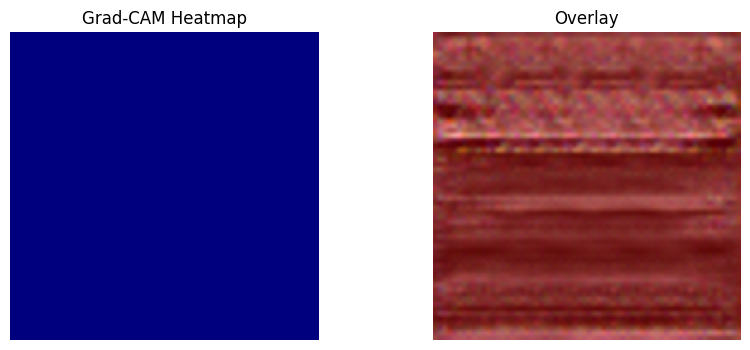

In [ ]:
cam, overlay = generate_gradcam("gan_generated_eval/fake_0.png", resnet)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.title("Grad-CAM Heatmap")
plt.imshow(cam, cmap="jet")
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Overlay")
plt.imshow(overlay)
plt.axis("off")

plt.show()


In [ ]:
# ============================================================
#   CELL 1 — LOAD BEST SAVED MODEL
# ============================================================

import numpy as np
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix
)

# load best checkpoint saved during training
model = resnet
model.load_state_dict(torch.load("resnet50_malware_image_branch.pth"))
model.eval()


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [ ]:
# ============================================================
#   CELL 2 — COLLECT PREDICTIONS & PROBABILITIES
# ============================================================

all_labels = []
all_preds  = []
all_probs  = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device).float()

        outputs = model(images)
        probs = torch.sigmoid(outputs).squeeze()  # convert logits → probabilities
        preds = (probs > 0.5).long()              # threshold at 0.5 = binary prediction

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

# numpy conversion
all_labels = np.array(all_labels)
all_preds  = np.array(all_preds)
all_probs  = np.array(all_probs)


=============== IMAGE BRANCH METRICS ================
Accuracy      : 0.8234
Precision     : 0.8578
Recall        : 0.8480
F1-Score      : 0.8529
ROC-AUC       : 0.8850


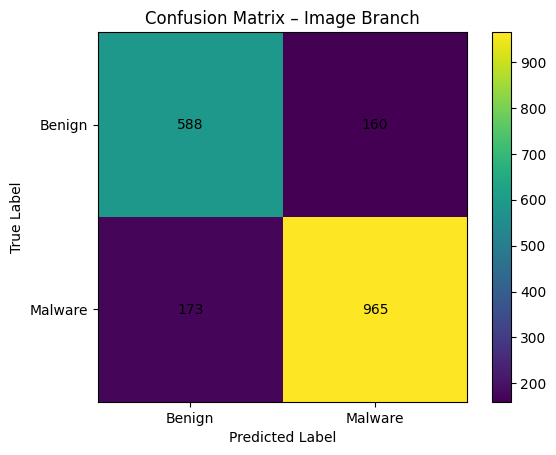

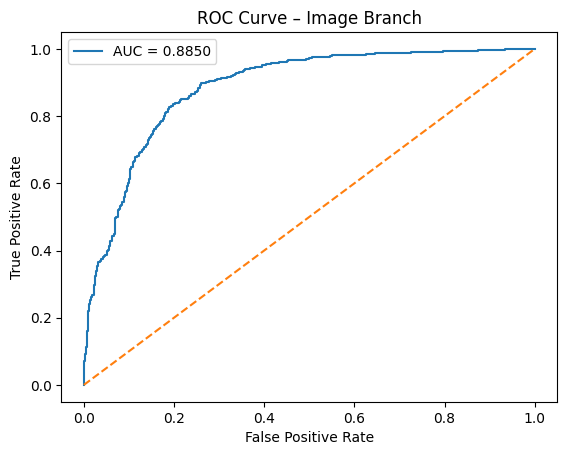

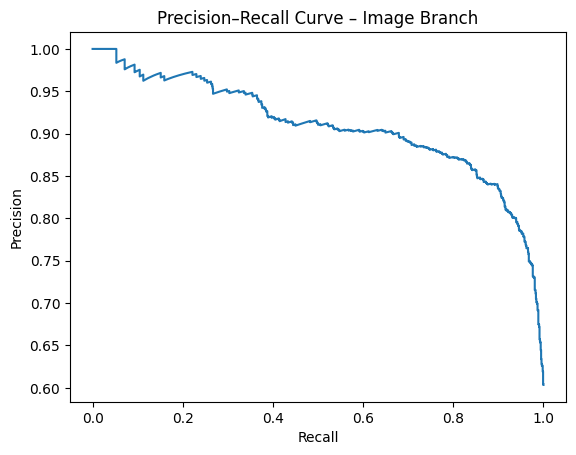

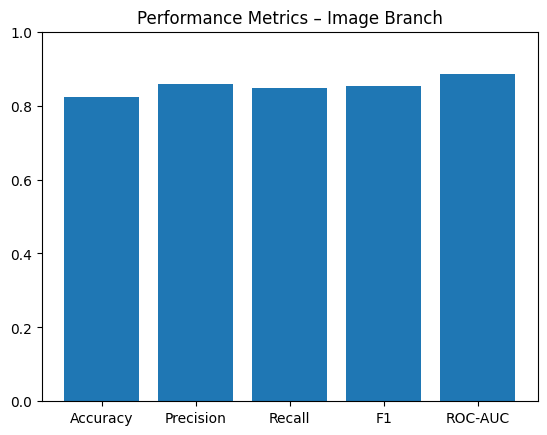

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score,
    confusion_matrix, roc_curve, precision_recall_curve
)

# ================================
# NUMERICAL METRICS
# ================================
acc  = accuracy_score(all_labels, all_preds)
prec = precision_score(all_labels, all_preds, zero_division=0)
rec  = recall_score(all_labels, all_preds, zero_division=0)
f1   = f1_score(all_labels, all_preds, zero_division=0)
auc  = roc_auc_score(all_labels, all_probs)

print("=============== IMAGE BRANCH METRICS ================")
print(f"Accuracy      : {acc:.4f}")
print(f"Precision     : {prec:.4f}")
print(f"Recall        : {rec:.4f}")
print(f"F1-Score      : {f1:.4f}")
print(f"ROC-AUC       : {auc:.4f}")

# ================================
# 1. CONFUSION MATRIX
# ================================
cm = confusion_matrix(all_labels, all_preds)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix – Image Branch")
plt.colorbar()
plt.xticks([0, 1], ["Benign", "Malware"])
plt.yticks([0, 1], ["Benign", "Malware"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# ================================
# 2. ROC CURVE
# ================================
fpr, tpr, _ = roc_curve(all_labels, all_probs)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Image Branch")
plt.legend()
plt.show()

# ================================
# 3. PRECISION–RECALL CURVE
# ================================
precision_vals, recall_vals, _ = precision_recall_curve(all_labels, all_probs)

plt.figure()
plt.plot(recall_vals, precision_vals)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve – Image Branch")
plt.show()

# ================================
# 4. METRICS BAR PLOT (OPTIONAL)
# ================================
metrics = [acc, prec, rec, f1, auc]
metric_names = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]

plt.figure()
plt.bar(metric_names, metrics)
plt.ylim(0, 1)
plt.title("Performance Metrics – Image Branch")
plt.show()


In [ ]:
import os

os.makedirs("fusion_outputs", exist_ok=True)
print("fusion_outputs directory ready")

fusion_outputs directory ready


In [ ]:
# Ensure tensors are on CPU and converted to numpy
probs_np  = probs.detach().cpu().numpy()
preds_np  = preds.detach().cpu().numpy()
labels_np = labels.detach().cpu().numpy()

import os
os.makedirs("fusion_outputs", exist_ok=True)

np.save("fusion_outputs/image_probs.npy", probs_np)
np.save("fusion_outputs/image_preds.npy", preds_np)
np.save("fusion_outputs/image_labels.npy", labels_np)

print("Image branch fusion inputs saved")


Image branch fusion inputs saved


In [ ]:
from google.colab import drive
drive.mount("/content/drive")

import os
import torch

BASE = "/content/drive/MyDrive/cyber_fusion_models"
IMAGE_DIR = os.path.join(BASE, "image_branch_artifact")
os.makedirs(IMAGE_DIR, exist_ok=True)

# Save model weights
torch.save(model.state_dict(), os.path.join(IMAGE_DIR, "model.pt"))

print("Image model weights saved")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Image model weights saved


In [ ]:
import json

image_meta = {
    "img_size": 224,        # or whatever you used
    "threshold": 0.5,       # or tuned threshold
    "mean": [0.485, 0.456, 0.406],
    "std":  [0.229, 0.224, 0.225],
    "model_type": "cnn"
}

with open(os.path.join(IMAGE_DIR, "meta.json"), "w") as f:
    json.dump(image_meta, f, indent=2)

print("Image inference metadata saved")


Image inference metadata saved


In [ ]:
import pandas as pd
from google.colab import drive
import os

drive.mount("/content/drive")

SAVE_DIR = "/content/drive/MyDrive/cyber_fusion_models/results"
os.makedirs(SAVE_DIR, exist_ok=True)

image_results = pd.DataFrame({
    "id": np.arange(len(all_labels)),
    "y_true": all_labels,
    "prob": all_probs   # sigmoid outputs
})

image_results.to_csv(f"{SAVE_DIR}/image_results.csv", index=False)
print("Image results saved.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Image results saved.


In [1]:
import torch
import numpy as np
from sklearn.metrics import matthews_corrcoef

def evaluate_mcc(model, dataloader, device):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            # Binary classification → sigmoid + threshold
            probs = torch.sigmoid(outputs)
            preds = (probs > 0.5).int()

            all_preds.extend(preds.cpu().numpy().flatten())
            all_labels.extend(labels.cpu().numpy().flatten())

    mcc = matthews_corrcoef(all_labels, all_preds)
    return mcc


In [2]:
mcc_score = evaluate_mcc(image_model, test_loader, device)
print(f"Image Branch MCC: {mcc_score:.4f}")


NameError: name 'image_model' is not defined